In [18]:
from sklearn import set_config
set_config(display='text')

In [19]:
import pandas as pd

df = pd.read_csv("..\premier-league-matches.csv")
#first look
print(df.shape)
print(df.head())
print(df.dtypes)
print(df.isnull().sum())

(12026, 8)
   Season_End_Year  Wk        Date            Home  HomeGoals  AwayGoals  \
0             1993   1  1992-08-15   Coventry City          2          1   
1             1993   1  1992-08-15    Leeds United          2          1   
2             1993   1  1992-08-15   Sheffield Utd          2          1   
3             1993   1  1992-08-15  Crystal Palace          3          3   
4             1993   1  1992-08-15         Arsenal          2          4   

             Away FTR  
0   Middlesbrough   H  
1       Wimbledon   H  
2  Manchester Utd   H  
3       Blackburn   D  
4    Norwich City   A  
Season_End_Year    int64
Wk                 int64
Date                 str
Home                 str
HomeGoals          int64
AwayGoals          int64
Away                 str
FTR                  str
dtype: object
Season_End_Year    0
Wk                 0
Date               0
Home               0
HomeGoals          0
AwayGoals          0
Away               0
FTR                0
dtype:

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\EQUIPO\AppData\Local\Temp\ipykernel_12440\4210472471.py:3: SyntaxWarning: invalid escape sequence '\p'
  df = pd.read_csv("..\premier-league-matches.csv")


# Step 1: Understand your target variable first

## predicting the match result: Home Win, Away Win, or Draw.

In [20]:
!pip install matplotlib

import matplotlib.pyplot as plt

#decode FTR into readable labels first 
df['result'] = df['FTR'].map({'H':'HOME WIN','A':'AWAY WIN','D':'DRAW'})

print(df['result'].value_counts())
print(df['result'].value_counts(normalize=True).round(3))


result
HOME WIN    5519
AWAY WIN    3410
DRAW        3097
Name: count, dtype: int64
result
HOME WIN    0.459
AWAY WIN    0.284
DRAW        0.258
Name: proportion, dtype: float64



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Step 2: Encode your features

## ML models can't read text. Everything needs to be a number. Team names, match results, all of that needs to be encoded.

### Developed and trained a multi-class ``Logistic Regression model`` to forecast match outcomes (Home Win, Away Win, or Draw) using encoded categorical team data.

In [21]:
from sklearn.preprocessing import LabelEncoder

#decode the result column first 
df['result'] = df['FTR'].map({'H':'HOME WIN','A':'AWAY WIN','D':'DRAW'})
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

#build pre-match rolling averages (what we'd actually know before kickoff)

df['home_goals_avg'] = df.groupby('Home')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['away_goals_avg'] = df.groupby('Away')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['home_conceded_avg'] = df.groupby('Home')['AwayGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)

df['away_conceded_avg'] = df.groupby('Away')['HomeGoals'].transform(
    lambda x: x.shift(1).rolling(5, min_periods=1).mean()
)
df = df.dropna()
le_home = LabelEncoder ()
le_away = LabelEncoder ()
le_result = LabelEncoder ()


df['home_encoded'] = le_home.fit_transform(df['Home'])
df['away_encoded'] = le_away.fit_transform(df['Away'])
df['result_encoded'] = le_result.fit_transform(df['result'])

# Step 3: Split your data

### train and test on different data. This is a rule. It's non-negotiable.

In [22]:
from sklearn.model_selection import train_test_split

features = ['home_encoded','away_encoded','home_goals_avg','away_goals_avg',
            'home_conceded_avg','away_conceded_avg']

X = df[features]
y = df['result_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,test_size = .2, random_state=42)

# Step 4: Train 

In [23]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter = 1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

# Step 4: Predict 

In [24]:
predictions = model.predict(X_test)

#decode numbers back into readable labels 
pred_labels = le_result.inverse_transform(predictions[:10])
print(pred_labels)
# ['Away win' 'Home win' Home win' ...]

['AWAY WIN' 'HOME WIN' 'HOME WIN' 'HOME WIN' 'HOME WIN' 'HOME WIN'
 'HOME WIN' 'HOME WIN' 'HOME WIN' 'AWAY WIN']


# Step 5: Validation

### Evaluated model performance using Scikit-Learn classification reports and visualized predictive accuracy and class distributions using Seaborn confusion matrices.

In [25]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,predictions))

0.4916317991631799


In [26]:
from sklearn.metrics import classification_report 
print(classification_report(y_test,predictions, target_names = le_result.classes_))

              precision    recall  f1-score   support

    AWAY WIN       0.43      0.31      0.36       654
        DRAW       0.00      0.00      0.00       628
    HOME WIN       0.51      0.88      0.64      1108

    accuracy                           0.49      2390
   macro avg       0.31      0.40      0.33      2390
weighted avg       0.35      0.49      0.40      2390



C:\Users\EQUIPO\Desktop\projects\premier_league_score\proj1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\EQUIPO\Desktop\projects\premier_league_score\proj1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\EQUIPO\Desktop\projects\premier_league_score\proj1\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.


In [27]:
from sklearn.metrics import confusion_matrix
!pip install seaborn
import seaborn as sns


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<Axes: >

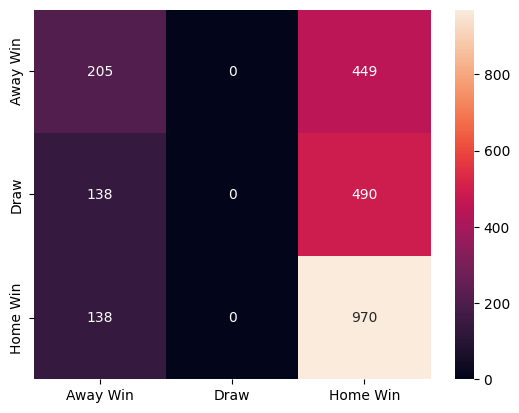

In [28]:
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot = True, fmt='d',
            xticklabels = ['Away Win', 'Draw', 'Home Win'],
            yticklabels = ['Away Win', 'Draw', 'Home Win'])